# The Solow Growth Model and its Convergence Prediction

Replication: A Contribution to the Empirics of Economic Growth by Mankiw, Romer, and Weil (1992)

- Is the Solow model of economic growth consistent with the cross-country data?
- What is the augmented Solow model? Is it consistent with the data?
- What are the implications of the Solow model for convergence in standards of living across countries?
- Do poor countries tend to grow faster than rich countries?

**REQUIRED BACKGROUND:** To follow the main ideas of this computational notebook, a [basic understanding of the Solow model](https://wke.lt/w/s/NOD3t3) is needed.

**NOTE**: Stata code to replicate the main tables and figures is [available in this Github gist](https://gist.github.com/cmg777/a1181c89de80e5eb5e8c8be2383342d1)

In [1]:
!pip install stargazer -q

In [2]:
# Import necessary libraries, sorted by popularity
import numpy as np                  # For numerical operations
import pandas as pd                 # For data manipulation and analysis
import matplotlib.pyplot as plt     # For plotting
import seaborn as sns               # For advanced plotting
import statsmodels.api as sm        # For statistical modeling
import statsmodels.formula.api as smf # For regression analysis
from IPython.display import IFrame  # For displaying HTML content in Jupyter Notebooks
from tabulate import tabulate       # For creating simple tables
from stargazer.stargazer import Stargazer, LineLocation

In [3]:
from math import log  # Import log function from the math module

In [4]:
IFrame("https://www.youtube.com/embed/md0cjl51JTk", width=560, height=315)

## Introduction

Solow (1956) proposed to study economic growth based on

  - A standard neoclassical production function with decreasing marginal returns to capital.
  - Exogenous rates of saving and population growth

Because saving and population growth rates vary across countries, different countries reach different steady states (long-run equilibria).

Testable predictions:

  - The higher the rate of saving, the richer the country.
  - The higher the rate of population growth, the poorer the country.

Motivation for including human capital accumulation:

  - The impact of higher savings (or lower population growth) is greater when human capital is taken into account. (Intuition: For a given (initially constant) $h$, $\uparrow s \Rightarrow  \uparrow y \Rightarrow \uparrow h \Rightarrow  \uparrow y$  )
  - Human capital may be correlated with savings and population growth rates. Thus, if it is omitted, the estimated coefficients are (upwardly) biased.

How to measure human capital accumulation?

  - Percentage of the working-age population tha is in secondary school.
  - Ignores investment in health, among other things


The Solow model and its convergence prediction:

  - In the data, countries do NOT convergence to the same per-capita income.
  - But recall that the Solow model predicts conditional convergence (multiple steady states), not unconditional convergence (single steady state)
      - Conditional convergence: countries converge to their own steady states, which are determined by saving, population growth, and education


## Dataset

In [5]:
# Read the Stata file
mrw_data = pd.read_stata("https://github.com/quarcs-lab/data-quarcs/raw/master/mrw1992/mrw2.dta")
mrw_data.head()

,number,country,region,n,i,o,rgdpw60,rgdpw85,gdpgrowth,popgrowth,i_y,school
0,1,Algeria,Africa,1,1,0,2485.0,4371.0,4.8,2.6,24.100000,4.5
1,2,Angola,Africa,1,0,0,1588.0,1171.0,0.8,2.1,5.800000,1.8
2,3,Benin,Africa,1,0,0,1116.0,1071.0,2.2,2.4,10.800000,1.8
3,4,Botswana,Africa,1,1,0,959.0,3671.0,8.6,3.2,28.299999,2.9
4,5,Burkina Faso,Africa,1,0,0,529.0,857.0,2.9,0.9,12.700000,0.4


In [6]:
# Display a statistical summary of the DataFrame
mrw_data.describe().round(2)

,number,n,i,o,rgdpw60,rgdpw85,gdpgrowth,popgrowth,i_y,school
count,121.00,121.00,121.00,121.00,116.00,108.00,117.00,107.00,121.00,118.00
mean,61.00,0.81,0.62,0.18,3681.82,5683.26,4.09,2.28,18.16,5.53
std,35.07,0.39,0.49,0.39,7492.88,5688.67,1.89,1.00,7.85,3.53
min,1.00,0.00,0.00,0.00,383.00,412.00,-0.90,0.30,4.10,0.40
25%,31.00,1.00,0.00,0.00,973.25,1209.25,2.80,1.70,12.00,2.40
50%,61.00,1.00,1.00,0.00,1962.00,3484.50,3.90,2.40,17.70,4.95
75%,91.00,1.00,1.00,0.00,4274.50,7718.75,5.30,2.90,24.10,8.18
max,121.00,1.00,1.00,1.00,77881.00,25635.00,9.20,6.80,36.90,12.10


In [7]:
# If you love the skim library of R for descriptive statistics, you can activate the code below and run it
#!pip install skimpy -q
#from skimpy import skim
#skim(mrw_data)

Rename variable names, so they are more meaningful.

In [8]:
# Rename the columns to facilite understanding
mrw_data = mrw_data.rename(columns={
    'n': 'non_oil',
    'o': 'oecd',
    'i': 'intermediate',
    'rgdpw60': 'gdp_60',
    'rgdpw85': 'gdp_85',
    'gdpgrowth': 'gdp_growth_60_85',
    'popgrowth': 'pop_growth_60_85',
    'i_y': 'inv_gdp',
    'school': 'school'
})

Create the key variables of the Solow model.

In [9]:
# Define delta_gamma
delta_gamma = 0.05

In [10]:
# Mutate the DataFrame
mrw_data = mrw_data.assign(
    ln_gdp_85       = np.log(mrw_data['gdp_85']),
    ln_gdp_60       = np.log(mrw_data['gdp_60']),
    ln_gdp_growth   = lambda x: x['ln_gdp_85'] - x['ln_gdp_60'],
    ln_inv_gdp      = np.log(mrw_data['inv_gdp'] / 100),
    non_oil         = mrw_data['non_oil'].astype('category'),
    intermediate    = mrw_data['intermediate'].astype('category'),
    oecd            = mrw_data['oecd'].astype('category'),
    ln_ndg          = np.log(mrw_data['pop_growth_60_85'] / 100 + delta_gamma),
    ln_school       = np.log(mrw_data['school'] / 100)
)


In [11]:
# Select the columns
mrw_data = mrw_data[[
    'country', 'region', 'ln_gdp_85', 'ln_gdp_60', 'ln_inv_gdp',
    'non_oil', 'intermediate', 'oecd',
    'ln_ndg', 'ln_school', 'gdp_growth_60_85', 'ln_gdp_growth'
]]

In [12]:
# Display the first few rows of the mutated DataFrame
mrw_data.head()

,country,region,ln_gdp_85,ln_gdp_60,ln_inv_gdp,non_oil,intermediate,oecd,ln_ndg,ln_school,gdp_growth_60_85,ln_gdp_growth
0,Algeria,Africa,8.382747,7.818028,-1.422958,1,1,0,-2.577022,-3.101093,4.8,0.564719
1,Angola,Africa,7.065613,7.370231,-2.847312,1,0,0,-2.645075,-4.017384,0.8,-0.304617
2,Benin,Africa,6.976348,7.017506,-2.225624,1,0,0,-2.603690,-4.017384,2.2,-0.041158
3,Botswana,Africa,8.208219,6.865891,-1.262308,1,1,0,-2.501036,-3.540459,8.6,1.342328
4,Burkina Faso,Africa,6.753438,6.270988,-2.063568,1,0,0,-2.830218,-5.521461,2.9,0.482449


- $n$: average growth rate of the working-age population (between 15 to 64 years)
- $s$: average share of real investment (including government investment) in GDP
- $Y/L$ is real GDP divided by the working-age population
- $g+\delta$ is assumed to be $0.02 + 0.03$

### Data samples

- Non-oil sample (98): Countries for which oil production is not the dominant industry. Intuition: extraction is not value added. Growth models do not account for extraction.
- Intermediate sample (75): Exclude countries whose populations were less than one million in 1960. Also exclude countries with data quality issues.
- OECD sample (22): Better data quality. In these countries, differences in country-specific factors ($\epsilon$) are likely to be small.

In [13]:
# Filter DataFrames
non_oil      = mrw_data[mrw_data['non_oil'] == 1]
intermediate = mrw_data[mrw_data['intermediate'] == 1]
oecd         = mrw_data[mrw_data['oecd'] == 1]

## Textbook Solow model

Consider the following Cobb-Douglas (1928, AER) [production function](https://youtu.be/qpaiuJA-nFU) and evolution of labor and technology:

$$
Y(t)=K(t)^{\alpha}(A(t) L(t))^{1-\alpha} \quad 0<\alpha<1
$$

$$
L(t)=L(0) e^{n t}
$$

$$
A(t)=A(0) e^{g t}
$$


- $Y$ is output, $K$ is physical capital, $L$ is labor, and $A$ is the level of technology.
- Assume perfect competition, so capital and labor are paid their marginal products.
- The number of [effective units of labor](https://youtu.be/7yeWBFzGHS4), $A(t)L(t)$, grows at rate $n+g$. Technological change is labor augmenting which is known as "Harrod-neutral".

- Assume that a constant fraction of output, $s$ ,  is invested. The remaining output is consumed.

- Define $k$ as the stock of capital per effective units of labor,
$$
k(t) = \frac{K(t)}{A(t) L(t) }
$$
- Define $y$ as the level of output per effective units of labor as
$$
\begin{aligned}
y(t) &=\frac{Y(t)}{A(t) L(t)} \\
&=K(t)^{\alpha}(A(t) L(t))^{-\alpha} \\
&=\left(\frac{K(t)}{(A(t) L(t))}\right)^{\alpha} \\
&=k(t)^{\alpha}
\end{aligned}
$$

The evolution of $k$ [(equation of motion for capital accumulation)](https://youtu.be/_xaeUluiCxw) is governed by:

$$
\begin{aligned}
\dot{k}(t) &=s y(t)-(n+g+\delta) k(t)  \\
&=s k(t)^{\alpha}-(n+g+\delta) k(t)
\end{aligned}
$$

The steady state is defined as the level of capital $k^{ss}$ at which $\dot{k}(t) = 0$, plugging this into the previous equation we have:

$$
k^{ss}=[s /(n+g+\delta)]^{1 /(1-\alpha)}
$$

Substituting the previous equation into the steady-state production of output per effective worker, we have

$$
y^{ss} = [s /(n+g+\delta)]^{\alpha /(1-\alpha)}
$$

Taking logs, we have

$$
\ln(y^{ss}) = \frac{\alpha}{1-\alpha} \ln (s) - \frac{\alpha}{1-\alpha} \ln (n+g+\delta)  
$$


$$
\ln \left[\frac{Y(t)}{A(t)L(t)}\right] = \frac{\alpha}{1-\alpha} \ln (s) - \frac{\alpha}{1-\alpha} \ln (n+g+\delta)  
$$


$$
\ln \left[\frac{Y(t)}{L(t)}\right] = \ln A(t) + \frac{\alpha}{1-\alpha} \ln (s) - \frac{\alpha}{1-\alpha} \ln (n+g+\delta)  
$$

Plugging in the evolution of technology equation, we have steady-state (log) production function of **output per worker**:

$$
\ln \left[\frac{Y(t)}{L(t)}\right] = \ln A(0)+g t+\frac{\alpha}{1-\alpha} \ln (s)-\frac{\alpha}{1-\alpha} \ln (n+g+\delta)  
$$

### Quantitative implications

- Because the capital's share of income ($\alpha$) is roughly 1/3, the elasticity of output per worker with respect to the saving rate ($\alpha /(1-\alpha)$) is approximately 0.5.


$$
\varepsilon_{ \frac{Y}{L}  , s} = \frac{d \log( \frac{Y}{L}  )}{ d \log(s) }
= \frac{\alpha}{1 - \alpha} \approx  \frac{ \frac{1}{3} }{ \frac{2}{3} } = \frac{1}{2}
$$


- Similarly, the elasticity of output per worker with respect to $n+g+\delta$ is approximately -0.5.


$$
\varepsilon_{ \frac{Y}{L}  , n+g+\delta} = \frac{d \log( \frac{Y}{L}  )}{ d \log(n+g+\delta) }
= - \frac{\alpha}{1 - \alpha} \approx - \frac{ \frac{1}{3} }{ \frac{2}{3} } = - \frac{1}{2}
$$

- [Conditional on similar "preferences and technologies"](https://youtu.be/SVWX4Xjl4Os?t=129), initially poor countries should grow faster than initially rich countries (for more details, refer to [the convergence section of this notebook](https://deepnote.com/project/R-Augmented-Solow-Model-2Q91UJCcQH2ClZuknoF2Tw/%2FR-augmented-Solow-model.ipynb#00061-ae9b07a9-b0ec-4965-a78c-f1c392aa1e99)).

### Econometric specification

$$
\ln \left[\frac{Y(t)}{L(t)}\right] = \ln A(0)+g t+\frac{\alpha}{1-\alpha} \ln (s)-\frac{\alpha}{1-\alpha} \ln (n+g+\delta)  
$$

- Assume $g$ and $\delta$ are constant across countries.
- $A(0)$ is NOT constant across countries. It reflects not only technology, but social organization, institutions, geography, and so on. Thus, assume that

$$
\ln A(0)= \beta_0 +\epsilon,  
$$
where $\beta_0 $ is constant and $\epsilon$ is a country-specific shock.


At time $0$ (for simplicity), the steady-state (log) production function of **output per worker** becomes:


$$
\ln \left[\frac{Y(t)}{L(t)}\right]  = \beta_0  +\frac{\alpha}{1-\alpha} \ln (s)-\frac{\alpha}{1-\alpha} \ln (n+g+\delta)+\epsilon  
$$

**STRONG assumption!!**: $s$ and $n$ are independent of $\epsilon$. So, we can estimate the previous equation with OLS.

### Unrestricted Regression

In [14]:
m1 = smf.ols(formula='ln_gdp_85 ~ ln_inv_gdp + ln_ndg', data = non_oil).fit()
m2 = smf.ols(formula='ln_gdp_85 ~ ln_inv_gdp + ln_ndg', data = intermediate).fit()
m3 = smf.ols(formula='ln_gdp_85 ~ ln_inv_gdp + ln_ndg', data = oecd).fit()

In [15]:
tab1 = Stargazer([m1, m2, m3])
tab1

In [16]:
# Deactivate to show latex table (you can use AI to display and improve this table)
#tab1_tex = tab1.render_latex()
#print(tab1_tex)

PROS:

- The signs of the coefficients on saving and population growth are correct
- The hypothesis that the coefficients on $\ln (s)$ and $\ln (n+g+\delta)$ are equal in magnitude and opposite in sign is NOT rejected by the data
- Differences in saving and population growth account for a large fraction of the differences in cross-country output per capita (Adj $R^2$ is 0.59).


CONS:

- The magnitude of the coefficients on saving and population growth is overstated. The implied $\alpha$ is larger than 1/3.

### Restricted Regression

In [17]:
m4 = smf.ols(formula='ln_gdp_85 ~ I(ln_inv_gdp - ln_ndg)', data = non_oil).fit()
m5 = smf.ols(formula='ln_gdp_85 ~ I(ln_inv_gdp - ln_ndg)', data = intermediate).fit()
m6 = smf.ols(formula='ln_gdp_85 ~ I(ln_inv_gdp - ln_ndg)', data = oecd).fit()

In [18]:
Stargazer([m4, m5, m6])

### Test of Restriction

H0: The coefficients on $\ln (s)$ and $\ln (n+g+\delta)$ are equal in magnitude and opposite in sign.

In [19]:
def perform_F_test(model, alpha=0.05):
    # Define the null hypothesis: ln_inv_gdp = -ln_ndg
    R = np.array([[0, 1, 1]])  # The three elements correspond to the intercept, ln_inv_gdp, and ln_ndg respectively. The 0 for the intercept means we're not including it in the hypothesis. The 1 for ln_inv_gdp and 1 for ln_ndg represent the equation: 1β₁ + 1β₂ = 0,
    r = np.array([0]) # This is the right-hand side of our hypothesis equation. It's saying that the linear combination defined in R should equal 0. In other words, 1β₁ + 1β₂ = 0, which is equivalent to β₁ = -β₂.

    # Perform the F-test
    hypothesis_test = model.f_test((R, r)) # Together, R and r define the linear constraint we're testing. In matrix notation, we're testing Rβ = r, where β is the vector of coefficients from our regression model.

    # Extract relevant statistics
    f_statistic = hypothesis_test.statistic
    p_value = hypothesis_test.pvalue
    df_num, df_denom = hypothesis_test.df_num, hypothesis_test.df_denom

    # Interpret the results
    reject_null = p_value < alpha
    interpretation = ("Reject" if reject_null else "Fail to reject") + " the null hypothesis"

    # Prepare the results
    results = {
        "F-statistic": f_statistic,
        "p-value": p_value,
        "Degrees of Freedom": (df_num, df_denom),
        "Reject Null": reject_null,
        "Interpretation": interpretation
    }

    return results

# Usage example:
# results = perform_F_test(model)
# print(results)

In [20]:
perform_F_test(m1)

{'F-statistic': 0.8342618417529412,
 'p-value': 0.3633553253507744,
 'Degrees of Freedom': (1.0, 95.0),
 'Reject Null': False,
 'Interpretation': 'Fail to reject the null hypothesis'}

In [21]:
perform_F_test(m2)

{'F-statistic': 1.2933270553751646,
 'p-value': 0.259206323694347,
 'Degrees of Freedom': (1.0, 72.0),
 'Reject Null': False,
 'Interpretation': 'Fail to reject the null hypothesis'}

In [22]:
perform_F_test(m3)

{'F-statistic': 0.06034111896218039,
 'p-value': 0.8085915052608879,
 'Degrees of Freedom': (1.0, 19.0),
 'Reject Null': False,
 'Interpretation': 'Fail to reject the null hypothesis'}

### Implied alpha

$$
\alpha = \frac{C}{1+C}
$$

In [23]:
def calculate_implied_alpha(model, coefficient_index=1, label=""):
    # Get the coefficients
    coefficients = model.params

    # Get the specific coefficient
    C = coefficients[coefficient_index]

    # Compute alpha
    alpha = C / (1 + C)

    # Round alpha to 2 decimal places
    alpha = round(alpha, 2)

    # Print the result
    print(f"Implied alpha{' (' + label + ')' if label else ''}: {alpha}")

    #return alpha

# Usage examples:
# alpha_m4 = calculate_implied_alpha(m4, label="Non oil")

In [24]:
calculate_implied_alpha(m4, label = "Non oil")

Implied alpha (Non oil): 0.6


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/3516823359.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C = coefficients[coefficient_index]


In [25]:
calculate_implied_alpha(m5, label = "Intermediate")

Implied alpha (Intermediate): 0.59


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/3516823359.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C = coefficients[coefficient_index]


In [26]:
calculate_implied_alpha(m6, label = "OECD")

Implied alpha (OECD): 0.36


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/3516823359.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C = coefficients[coefficient_index]


## Augmented Solow model

Add human capital accumulation to the Solow model.

$$
Y(t)=K(t)^{\alpha} H(t)^{\beta}(A(t) L(t))^{1-\alpha-\beta}
$$


$$
\begin{aligned}
y &=\frac{Y}{A L} \\
&=\frac{K^{\alpha} H^{\beta}(A L)^{1-\alpha-\beta}}{A L} \\
&=K^{\alpha} H^{\beta}(A L)^{-\alpha-\beta} \\
&=K^{\alpha} H^{\beta}(A L)^{-\alpha}(A L)^{-\beta} \\
&=\left(\frac{K}{A L}\right)^{\alpha}\left(\frac{H}{A L}\right)^{\beta}
\end{aligned}
$$


$$
y(t)=k(t)^{\alpha} h(t)^{\beta}
$$

- $s_k$: fraction of income invested in physical capital
- $s_h$: fraction of income invested in human capital

$$
\dot{k}(t)=s_{k} y(t)-(n+g+\delta) k(t)
$$

$$
\dot{h}(t)=s_{h} y(t)-(n+g+\delta) h(t)
$$

- $h(t) = H(t)/A(t)L(t)$: Human capital per effective unit of labor
- Assume that human capital depreciates at the same rate than physical capital
- Assume $\alpha + \beta <1$, which implies diminishing returns for all capital

Substituting the steady-state physical and human capital into the production function, we have an expresion of steady-state **output per effective worker**:

$$
y^{ss}=\left(k^{ss}\right)^{\alpha}\left(h^{ss}\right)^{\beta}
$$


$$
y^{ss}=\left(\frac{s_{k}^{1-\beta} s_{h}^{\beta}}{n+g+\delta}\right)^{\alpha /(1-\alpha-\beta)} \left(\frac{s_{k}^{\alpha} s_{h}^{1-\alpha}}{n+g+\delta}\right)^{\beta /(1-\alpha-\beta)}
$$

\begin{aligned}
\left(\frac{s_{k}^{\alpha} s_{h}^{\beta}}{(n+g+\delta)^{\alpha+\beta}}\right)^{\frac{1}{1-\alpha-\beta}} &= \frac{Y(t)}{A(t) L(t)} \\
\frac{Y(t)}{A(t) L(t)} &= \left(\frac{s_{k}^{\alpha} s_{h}^{\beta}}{(n+g+\delta)^{\alpha+\beta}}\right)^{\frac{1}{1-\alpha-\beta}} \\
\frac{Y(t)}{L(t)} &= A(0) e^{g t} \left(\frac{s_{k}^{\alpha} s_{h}^{\beta}}{(n+g+\delta)^{\alpha+\beta}}\right)^{\frac{1}{1-\alpha-\beta}}
\end{aligned}

Taking logs and re-expresing the production function in **output per worker**  terms, we have

$$
\ln \left[\frac{Y(t)}{L(t)}\right]=\ln A(0)+g t-\frac{\alpha+\beta}{1-\alpha-\beta} \ln (n+g+\delta) +\frac{\alpha}{1-\alpha-\beta} \ln \left(s_{k}\right)+\frac{\beta}{1-\alpha-\beta} \ln \left(s_{h}\right)
$$

Instead of using the rate of human capital accumulation ($s_h$), we can also use the  level of human capital in steady state ($h^*$). In this case, we have

$$
\ln \left[\frac{Y(t)}{L(t)}\right]=\ln A(0)+g t -\frac{\alpha}{1-\alpha} \ln (n+g+\delta) +\frac{\alpha}{1-\alpha} \ln \left(s_{k}\right) +\frac{\beta}{1-\alpha} \ln \left(h^{ss}\right)
$$

How to measure investment in human capital ($s_h$)?

- Percentage of working-age population that is enrolled in secondary school
    - First identify the fraction of the population enrolled in secondary school (aged 12 to 17)
    - Next, multiply this enrollment rate by the fraction of the working-age population that is of school age (aged 15 to 19)
- This is a highly imperfect measure, the age ranges are not even the same.

### Unrestricted regression

In [27]:
m7 = smf.ols(formula='ln_gdp_85 ~ ln_inv_gdp  + ln_school + ln_ndg', data = non_oil).fit()
m8 = smf.ols(formula='ln_gdp_85 ~ ln_inv_gdp  + ln_school + ln_ndg', data = intermediate).fit()
m9 = smf.ols(formula='ln_gdp_85 ~ ln_inv_gdp  + ln_school + ln_ndg', data = oecd).fit()

In [28]:
Stargazer([m7, m8, m9])

- Human capital is significant in all three samples
- It reduces the size of the coefficient on physical capital
- It improves the fit of the regression. Almost 80% in the non-oil and intermediate samples
- The coefficients on $\ln (I/Y)$, $\ln (SCHOOL)$, and $\ln (n+g+\delta)$ sum to zero (close?)

### Restricted regression

In [29]:
m10 = smf.ols(formula='ln_gdp_85 ~ I(ln_inv_gdp - ln_ndg)+I(ln_school  - ln_ndg)', data = non_oil).fit()
m11 = smf.ols(formula='ln_gdp_85 ~ I(ln_inv_gdp - ln_ndg)+I(ln_school  - ln_ndg)', data = intermediate).fit()
m12 = smf.ols(formula='ln_gdp_85 ~ I(ln_inv_gdp - ln_ndg)+I(ln_school  - ln_ndg)', data = oecd).fit()

In [30]:
Stargazer([m10, m11, m12])

### Test of restriction

In [31]:
def perform_F_test(model, alpha=0.05):
    # Define the hypothesis: ln_inv_gdp + ln_ndg + ln_school = 0
    # The four elements correspond to the intercept, ln_school, ln_inv_gdp, and ln_ndg respectively
    R = np.array([[0, 1, 1, 1]])  # The linear combination for ln_inv_gdp, ln_ndg, and ln_school
    r = np.array([0])  # The right-hand side of the equation, i.e., we want the linear combination to equal 0

    # Perform the F-test
    hypothesis_test = model.f_test((R, r))  # We are testing the hypothesis Rβ = r

    # Extract relevant statistics
    f_statistic = hypothesis_test.statistic
    p_value = hypothesis_test.pvalue
    df_num, df_denom = hypothesis_test.df_num, hypothesis_test.df_denom

    # Interpret the results
    reject_null = p_value < alpha
    interpretation = ("Reject" if reject_null else "Fail to reject") + " the null hypothesis"

    # Prepare the results
    results = {
        "F-statistic": f_statistic,
        "p-value": p_value,
        "Degrees of Freedom": (df_num, df_denom),
        "Reject Null": reject_null,
        "Interpretation": interpretation
    }

    return results

# Example usage:
# results = perform_F_test(model)
# print(results)

In [32]:
perform_F_test(m7)

{'F-statistic': 0.74442442498961,
 'p-value': 0.39044322628589667,
 'Degrees of Freedom': (1.0, 94.0),
 'Reject Null': False,
 'Interpretation': 'Fail to reject the null hypothesis'}

In [33]:
perform_F_test(m8)

{'F-statistic': 0.021891735040966205,
 'p-value': 0.8827948681914718,
 'Degrees of Freedom': (1.0, 71.0),
 'Reject Null': False,
 'Interpretation': 'Fail to reject the null hypothesis'}

In [34]:
perform_F_test(m9)

{'F-statistic': 0.0013506865648775994,
 'p-value': 0.9710875170382884,
 'Degrees of Freedom': (1.0, 18.0),
 'Reject Null': False,
 'Interpretation': 'Fail to reject the null hypothesis'}

- For all three samples, the restriction is NOT rejected.

### Implied alpha and beta

From the restricted regression we have two coefficients:

$$
c2 = \alpha/(1- \alpha -\beta)
$$

$$
c3 = \beta/(1-\alpha -\beta)
$$


Solving this system of equatiations we have:

$$
\alpha = c2/ (c2 + c3 +1)
$$

$$
\beta = c3/ (c2 + c3 + 1)
$$

In [35]:
def calculate_implied_alpha_beta(model, coefficient2=1, coefficient3=2, label=""):
    # Get the coefficients
    coefficients = model.params

    # Get the specific coefficients
    C2 = coefficients[coefficient2]
    C3 = coefficients[coefficient3]
    # Compute alpha
    alpha = C2 / (1 + C2+C3)
    beta= C3 / (1 + C2+C3)
    # Round alpha to 2 decimal places
    alpha = round(alpha, 2)
    beta= round(beta, 2)
    # Print the result
    print(f"Implied alpha{' (' + label + ')' if label else ''}: {alpha}")
    print(f"Implied beta{' (' + label + ')' if label else ''}: {beta}")
    #return alpha

# Usage examples:
# alpha_m4 = calculate_implied_alpha(m4, label="Non oil")

In [36]:
calculate_implied_alpha_beta(m10, label = "Non oil")

Implied alpha (Non oil): 0.31
Implied beta (Non oil): 0.27


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/1972195597.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C2 = coefficients[coefficient2]
/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/1972195597.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C3 = coefficients[coefficient3]


In [37]:
calculate_implied_alpha_beta(m11, label = "Intermediate")

Implied alpha (Intermediate): 0.29
Implied beta (Intermediate): 0.3


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/1972195597.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C2 = coefficients[coefficient2]
/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/1972195597.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C3 = coefficients[coefficient3]


In [38]:
calculate_implied_alpha_beta(m12, label = "OECD")

Implied alpha (OECD): 0.14
Implied beta (OECD): 0.37


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/1972195597.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C2 = coefficients[coefficient2]
/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/1972195597.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C3 = coefficients[coefficient3]


- For non-oil and intermediate samples, $\alpha$ and $\beta$ are about one third and highly significant
- For the OECD sample, the estimates are less precise.

## Convergence

In [39]:
IFrame("https://www.youtube.com/embed/3OES78zU4lc", width=560, height=315)

The Solow model makes  predictions about convergence (watch [Video 1](https://youtu.be/2qzuRTrzdwU), [Video 2](https://youtu.be/3OES78zU4lc), and [Video 3](https://youtu.be/1t73mbEbBDI)) and [the speed of convergence (Video 4)](https://youtu.be/mG-es_Iqn_0) to steady state.

Approximating around the steady state, the speed of convergence is given by

$$
\frac{d \ln (y(t))}{d t}=\lambda\left[\ln \left(y^{*}\right)-\ln (y(t))\right],
$$

where

$$
\lambda=(n+g+\delta)(1-\alpha-\beta)
$$

For instance, if $\alpha=\beta=1/3$ and $n+g+\delta= 0.06$, then the convergence rate $\lambda$ would be equal to 0.02. This implies that the economy moves halfway to steady state in about 35 years.

The Solow model suggests the following regression to study convergence

$$
\ln (y(t))=\left(1-e^{-\lambda t}\right) \ln \left(y^{ss}\right)+e^{-\lambda t} \ln (y(0))
$$

Substracting $\ln (y(0))$ from both sides

$$
\ln (y(t))-\ln (y(0))=\left(1-e^{-\lambda t}\right) \ln \left(y^{ss}\right)-\left(1-e^{-\lambda t}\right) \ln (y(0))
$$

Substituting for $y^{ss}$:


$$
\begin{aligned}
\ln (y(t))-\ln (y(0)) &=\left(1-e^{-\lambda t}\right) \frac{\alpha}{1-\alpha-\beta} \log \left(s_{k}\right) \\
&+\left(1-e^{-\lambda t}\right) \frac{\beta}{1-\alpha-\beta} \log \left(s_{h}\right) \\
&-\left(1-e^{-\lambda t}\right) \frac{\alpha+\beta}{1-\alpha-\beta} \log (n+g+\delta) \\
& -\left(1-e^{-\lambda t}\right) \ln (y(0))
\end{aligned}
$$

Thus, in the Solow model, growth is a function of the determinants of steady state and the initial level of income.

Econometrically, we will be estimating

$$
\begin{aligned}
\left(Y/L_{1985}\right)-\ln \left(Y/L_{1960}\right) & = \beta_{0}+\beta_{1} \ln \left(Y/L_{1960}\right) \\
&+ \beta_{2} \ln (I / Y)+\beta_{3} \ln (n+g+\delta) \\
&+ \beta_{4} \ln (school) +\varepsilon
\end{aligned}
$$

### Unconditional convergence

In [40]:
m13 = smf.ols(formula='ln_gdp_growth ~ ln_gdp_60', data = non_oil).fit()
m14 = smf.ols(formula='ln_gdp_growth ~ ln_gdp_60', data = intermediate).fit()
m15 = smf.ols(formula='ln_gdp_growth ~ ln_gdp_60', data = oecd).fit()

In [41]:
Stargazer([m13, m14, m15])

### Implied speed of convergence


In [42]:
def implied_speed(model, coefficient_index=1, label=""):
    # Get the coefficients
    coefficients = model.params

    # Get the specific coefficient
    C = coefficients[coefficient_index]

    # Calculate Speed
    speed =-log(1+C)/(1985-1960)
    halflife=log(2)/speed

    # Round speed and halflife to 2 decimal places
    speed = round(speed,5)
    halflife = round(halflife, 2)
    # Print the result
    print(f"Implied speed of unconditional{' (' + label + ')' if label else ''}: {speed}")
    print(f"Implied halflife of unconditional{' (' + label + ')' if label else ''}: {halflife}")

In [43]:
implied_speed(m13, label = "Non oil")

Implied speed of unconditional (Non oil): -0.0036
Implied halflife of unconditional (Non oil): -192.27


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/3689424972.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C = coefficients[coefficient_index]


In [44]:
implied_speed(m14, label = "Intermediate")

Implied speed of unconditional (Intermediate): 0.00017
Implied halflife of unconditional (Intermediate): 4083.04


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/3689424972.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C = coefficients[coefficient_index]


In [45]:
implied_speed(m15, label = "OECD")

Implied speed of unconditional (OECD): 0.01669
Implied halflife of unconditional (OECD): 41.54


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/3689424972.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C = coefficients[coefficient_index]


- For the non-oil and intermediate samples, there is no tendency for poor countries to grow faster on average than rich countries.
- For the OECD sample, there is uncoditional convergence
    - The annual speed of convergence is 1.67 percent per year.
    - Fifty percent of gap to steady state would be closed in 42 years.

### Conditional convergence

In [46]:
m16 = smf.ols(formula='ln_gdp_growth ~ ln_gdp_60+ ln_inv_gdp + ln_ndg', data = non_oil).fit()
m17 = smf.ols(formula='ln_gdp_growth ~ ln_gdp_60+ ln_inv_gdp + ln_ndg', data = intermediate).fit()
m18 = smf.ols(formula='ln_gdp_growth ~ ln_gdp_60+ ln_inv_gdp + ln_ndg', data = oecd).fit()

In [47]:
Stargazer([m16, m17, m18])

- Strong evidence of conditional convergence.
- Improvement in the fit of the regression.

### Implied speed of convergence

In [48]:
implied_speed(m16, label = "Non oil")

Implied speed of unconditional (Non oil): 0.00607
Implied halflife of unconditional (Non oil): 114.1


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/3689424972.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C = coefficients[coefficient_index]


In [49]:
implied_speed(m17, label = "Intermediate")

Implied speed of unconditional (Intermediate): 0.01034
Implied halflife of unconditional (Intermediate): 67.02


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/3689424972.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C = coefficients[coefficient_index]


In [50]:
implied_speed(m18, label = "OECD")

Implied speed of unconditional (OECD): 0.01723
Implied halflife of unconditional (OECD): 40.24


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/3689424972.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C = coefficients[coefficient_index]


### Augmented conditional convergence

In [51]:
m19 = smf.ols(formula='ln_gdp_growth ~ ln_gdp_60+ ln_inv_gdp + ln_ndg + ln_school', data = non_oil).fit()
m20 = smf.ols(formula='ln_gdp_growth ~ ln_gdp_60+ ln_inv_gdp + ln_ndg + ln_school', data = intermediate).fit()
m21 = smf.ols(formula='ln_gdp_growth ~ ln_gdp_60+ ln_inv_gdp + ln_ndg + ln_school', data = oecd).fit()

In [52]:
Stargazer([m19, m20, m21])

### Implied speed of convergence

In [53]:
implied_speed(m19, label = "Non oil")

Implied speed of unconditional (Non oil): 0.01361
Implied halflife of unconditional (Non oil): 50.94


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/3689424972.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C = coefficients[coefficient_index]


In [54]:
implied_speed(m20, label = "Intermediate")

Implied speed of unconditional (Intermediate): 0.01823
Implied halflife of unconditional (Intermediate): 38.03


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/3689424972.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C = coefficients[coefficient_index]


In [55]:
implied_speed(m21, label = "OECD")

Implied speed of unconditional (OECD): 0.02028
Implied halflife of unconditional (OECD): 34.18


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/3689424972.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C = coefficients[coefficient_index]


### Restricted augmented conditional convergence

In [56]:
m22 = smf.ols(formula='ln_gdp_growth ~ ln_gdp_60 + I(ln_inv_gdp - ln_ndg) + I(ln_school - ln_ndg)', data = non_oil).fit()
m23 = smf.ols(formula='ln_gdp_growth ~ ln_gdp_60 + I(ln_inv_gdp - ln_ndg) + I(ln_school - ln_ndg)', data = intermediate).fit()
m24 = smf.ols(formula='ln_gdp_growth ~ ln_gdp_60 + I(ln_inv_gdp - ln_ndg) + I(ln_school - ln_ndg)', data = oecd).fit()

In [57]:
Stargazer([m22, m23, m24])

### Test of restriction

In [58]:
def perform_F_test_conv(model, alpha=0.05):
    # Define the hypothesis: ln_inv_gdp + ln_ndg + ln_school = 0
    # The four elements correspond to the intercept, ln_school, ln_inv_gdp, and ln_ndg respectively
    R = np.array([[0, 0, 1, 1, 1]])  # The linear combination for ln_inv_gdp, ln_ndg, and ln_school
    r = np.array([0])  # The right-hand side of the equation, i.e., we want the linear combination to equal 0

    # Perform the F-test
    hypothesis_test = model.f_test((R, r))  # We are testing the hypothesis Rβ = r

    # Extract relevant statistics
    f_statistic = hypothesis_test.statistic
    p_value = hypothesis_test.pvalue
    df_num, df_denom = hypothesis_test.df_num, hypothesis_test.df_denom

    # Interpret the results
    reject_null = p_value < alpha
    interpretation = ("Reject" if reject_null else "Fail to reject") + " the null hypothesis"

    # Prepare the results
    results = {
        "F-statistic": f_statistic,
        "p-value": p_value,
        "Degrees of Freedom": (df_num, df_denom),
        "Reject Null": reject_null,
        "Interpretation": interpretation
    }

    return results

# Example usage:
# results = perform_F_test(model)
# print(results)

In [59]:
perform_F_test_conv(m19)

{'F-statistic': 0.692583947668553,
 'p-value': 0.4074187959423258,
 'Degrees of Freedom': (1.0, 93.0),
 'Reject Null': False,
 'Interpretation': 'Fail to reject the null hypothesis'}

In [60]:
perform_F_test_conv(m20)

{'F-statistic': 0.703486720026097,
 'p-value': 0.4044696963410733,
 'Degrees of Freedom': (1.0, 70.0),
 'Reject Null': False,
 'Interpretation': 'Fail to reject the null hypothesis'}

In [61]:
perform_F_test_conv(m21)

{'F-statistic': 0.6174239078903273,
 'p-value': 0.4428211016556468,
 'Degrees of Freedom': (1.0, 17.0),
 'Reject Null': False,
 'Interpretation': 'Fail to reject the null hypothesis'}

The restriction is NOT rejected, and imposing it has little effect on the coefficients.

### Implied speed of convergence

In [62]:
implied_speed(m22, label = "Non oil")

Implied speed of unconditional (Non oil): 0.01415
Implied halflife of unconditional (Non oil): 49.0


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/3689424972.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C = coefficients[coefficient_index]


In [63]:
implied_speed(m23, label = "Intermediate")

Implied speed of unconditional (Intermediate): 0.01863
Implied halflife of unconditional (Intermediate): 37.2


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/3689424972.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C = coefficients[coefficient_index]


In [64]:
implied_speed(m24, label = "OECD")

Implied speed of unconditional (OECD): 0.02058
Implied halflife of unconditional (OECD): 33.68


/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T/ipykernel_88276/3689424972.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C = coefficients[coefficient_index]


### Figures: Unconditional vs conditional convergence

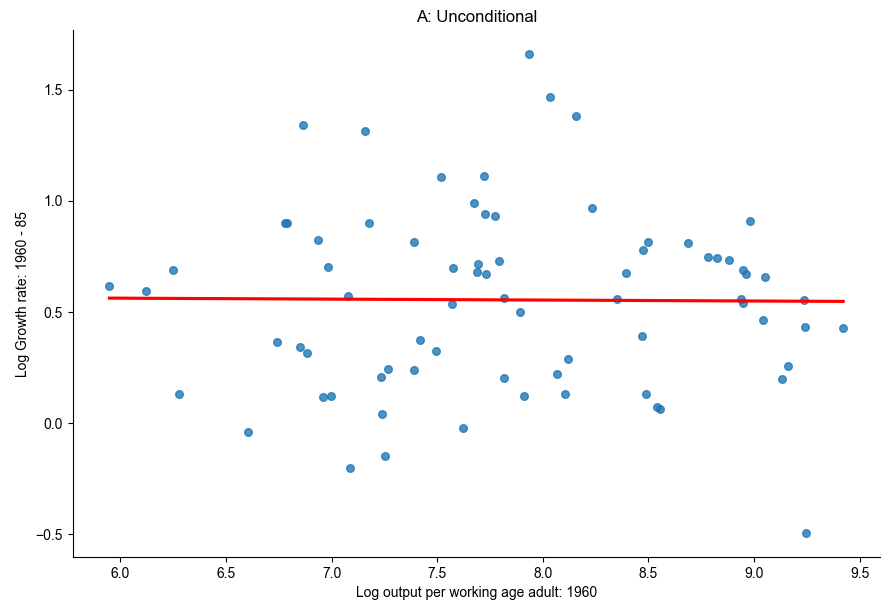

In [65]:
# Create a scatter plot with a linear fit using seaborn, without the confidence interval
sns.lmplot(data=intermediate, x='ln_gdp_60', y='ln_gdp_growth',
           scatter_kws={'s': 30, 'marker': 'o'},
           line_kws={'color': 'red'},
           ci=None,  # Exclude confidence interval
           height=6, aspect=1.5)

# Set the title and labels
plt.title("A: Unconditional")
plt.xlabel("Log output per working age adult: 1960")
plt.ylabel("Log Growth rate: 1960 - 85")

# Apply the 'whitegrid' theme (seaborn provides themes that you can set directly)
sns.set_theme(style='whitegrid')

# Show the plot
plt.show()

In [66]:
# Perform the linear regressions and extract residuals
model_y2 = sm.OLS(intermediate['ln_gdp_growth'], sm.add_constant(intermediate[['ln_inv_gdp', 'ln_ndg']])).fit()
y2_residuals = model_y2.resid

model_x2 = sm.OLS(intermediate['ln_gdp_60'], sm.add_constant(intermediate[['ln_inv_gdp', 'ln_ndg']])).fit()
x2_residuals = model_x2.resid

# Create a DataFrame with the residuals
panel_b = pd.DataFrame({'y2': y2_residuals, 'x2': x2_residuals})

# Display the DataFrame
print(panel_b.head())

          y2        x2
0  -0.127303 -0.159361
3   0.578177 -1.097754
6   0.493004 -0.774332
11  0.109394 -0.479057
16 -0.188527  0.242589


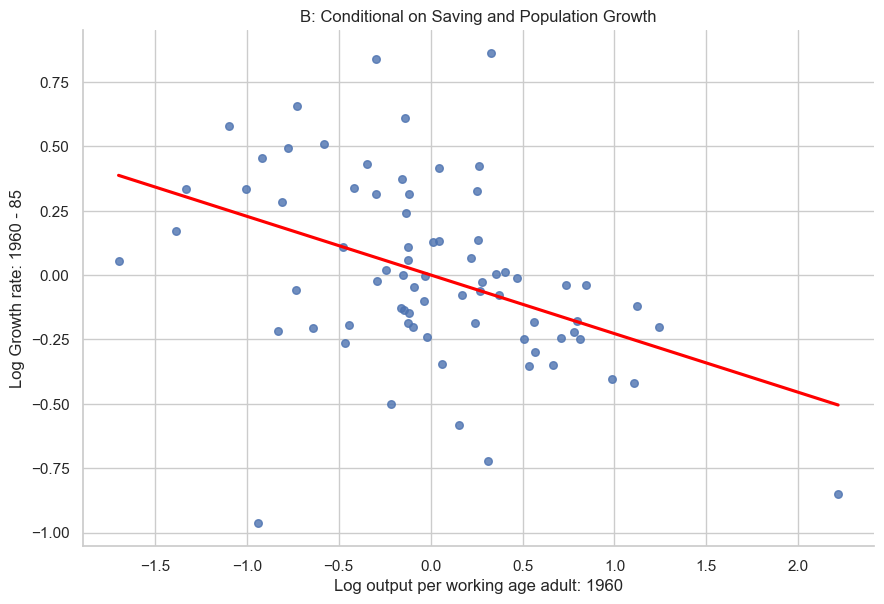

In [67]:
# Create the scatter plot with a linear fit
sns.lmplot(data=panel_b, x='x2', y='y2',
           scatter_kws={'s': 30, 'marker': 'o'},
           line_kws={'color': 'red'},
           height=6, aspect=1.5, ci=None)  # ci=None removes the confidence interval band

# Set the title and labels
plt.title("B: Conditional on Saving and Population Growth")
plt.xlabel("Log output per working age adult: 1960")
plt.ylabel("Log Growth rate: 1960 - 85")

# Show the plot
plt.show()

In [68]:
# Define the function to get residuals from a linear model
def get_residuals(data, dependent_var, independent_vars):
    # Set up the model
    X = data[independent_vars]
    X = sm.add_constant(X)  # Adds a constant term to the predictor
    y = data[dependent_var]

    # Fit the model
    model = sm.OLS(y, X).fit()

    # Get residuals
    residuals = model.resid
    return residuals

# Define the variables
independent_vars = ['ln_inv_gdp', 'ln_ndg', 'ln_school']

# Get residuals for y3 and x3
y3 = get_residuals(intermediate, 'ln_gdp_growth', independent_vars)
x3 = get_residuals(intermediate, 'ln_gdp_60', independent_vars)

# Create the DataFrame
panel_c = pd.DataFrame({'y3': y3, 'x3': x3})

# Display the DataFrame
print(panel_c.head())

          y3        x3
0  -0.125473  0.114032
3   0.582538 -0.446079
6   0.493833 -0.650486
11  0.112066 -0.079689
16 -0.186859  0.491886


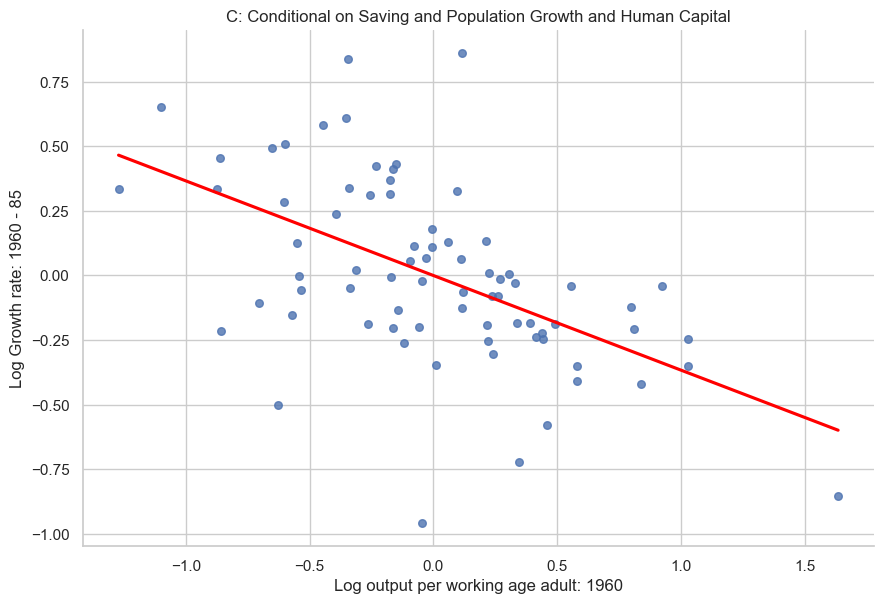

In [69]:
# Create the scatter plot with a linear fit using seaborn
sns.lmplot(data=panel_c, x='x3', y='y3',
           scatter_kws={'s': 30, 'marker': 'o'},
           line_kws={'color': 'red'},
           height=6, aspect=1.5,
           ci=None)  # ci=None to remove the confidence interval

# Set the title and labels
plt.title("C: Conditional on Saving and Population Growth and Human Capital")
plt.xlabel("Log output per working age adult: 1960")
plt.ylabel("Log Growth rate: 1960 - 85")

# Show the plot
plt.show()

## Conclusions

Is the textbook Solow model consistent with the cross-country data?

- To some extent: the directions of the effects  are right.
- But, the magnitudes of the effects are over estimated.

What is the augmented Solow model? Is it consistent with the data?

- Yes

What are the implications of the Solow model for convergence in standards of living?

- Holding population growth and capital accumulation constant, poor countries tend to grow faster than rich countries. Countries tend to convergence at the rate predicted by the augmented Solow model.

- More than half (about 80 percent!!) of the cross-country variation in income per capita can be explained by differences in savings rates and population growth
    - "The augmented Solow models provides and almost complete explanation of why some countries are rich and other countries are poor"
    - The Solow model should not be dismissed in favor of endogenous growth models with constant or increasing marginal returns to capital.

Next question: What are the determinants of capital accumulation and technological change?

## Acknowledgements

The code of this notebook is largely based on that of [Lachlan Deer](https://lachlandeer.github.io/) & [Julian Langer](https://www.julianlanger.org/)

The translation to Python was prepared with the assistance of ChatGPT by [Favio Leiva](https://favioleiva.github.io/) from Quarcs.